In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

print("Dataset loaded successfully!")
print("Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

Dataset loaded successfully!
Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   



In [3]:
# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Fill missing values
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

# Convert target variable
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

print("Data preparation completed!")
print("Missing values in TotalCharges:", data["TotalCharges"].isnull().sum())

Data preparation completed!
Missing values in TotalCharges: 0


In [4]:
# Remove customer ID
pca_data = data.drop(columns=["customerID"])

# Separate target
y = pca_data["Churn"]
X = pca_data.drop(columns=["Churn"])

# One-hot encode categorical variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object"]).columns,
    drop_first=True,
    dtype=int
)

print("Encoding completed!")
print("Feature shape:", X.shape)

Encoding completed!
Feature shape: (7043, 30)


C:\Users\aatik\AppData\Local\Temp\ipykernel_12480\2875701236.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns=X.select_dtypes(include=["object"]).columns,


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Scaled training shape:", X_train_scaled.shape)

Feature scaling completed!
Scaled training shape: (5634, 30)


In [7]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA completed successfully!")
print("Original number of features:", X_train.shape[1])
print("Reduced number of components:", X_train_pca.shape[1])

PCA completed successfully!
Original number of features: 30
Reduced number of components: 2


In [8]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print("Principal Component 1:", explained_variance[0])
print("Principal Component 2:", explained_variance[1])

print("\nTotal variance retained:",
      explained_variance.sum())

Explained Variance Ratio:
Principal Component 1: 0.3324615149389377
Principal Component 2: 0.11980320933777568

Total variance retained: 0.4522647242767134


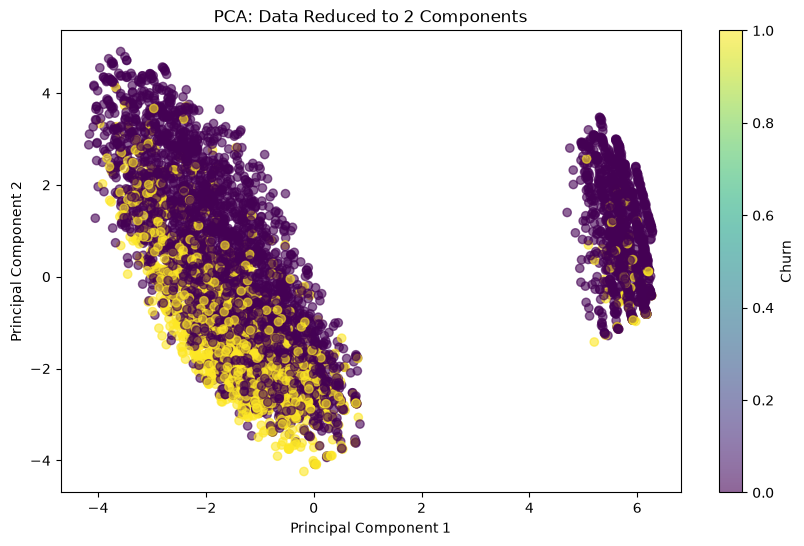

In [9]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Data Reduced to 2 Components")
plt.colorbar(scatter, label="Churn")
plt.show()

In [10]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.8069552874378992


In [11]:
pca_model = LogisticRegression(max_iter=1000)

pca_model.fit(X_train_pca, y_train)

pca_predictions = pca_model.predict(X_test_pca)

pca_accuracy = accuracy_score(
    y_test,
    pca_predictions
)

print("PCA Model Accuracy:", pca_accuracy)

PCA Model Accuracy: 0.7679205110007097


In [14]:
performance_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - Original Features",
        "Logistic Regression - PCA (2 Components)"
    ],
    "Number of Features": [
        X_train.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        baseline_accuracy,
        pca_accuracy
    ]
})

print(performance_comparison)

                                      Model  Number of Features  Accuracy
0   Logistic Regression - Original Features                  30  0.806955
1  Logistic Regression - PCA (2 Components)                   2  0.767921


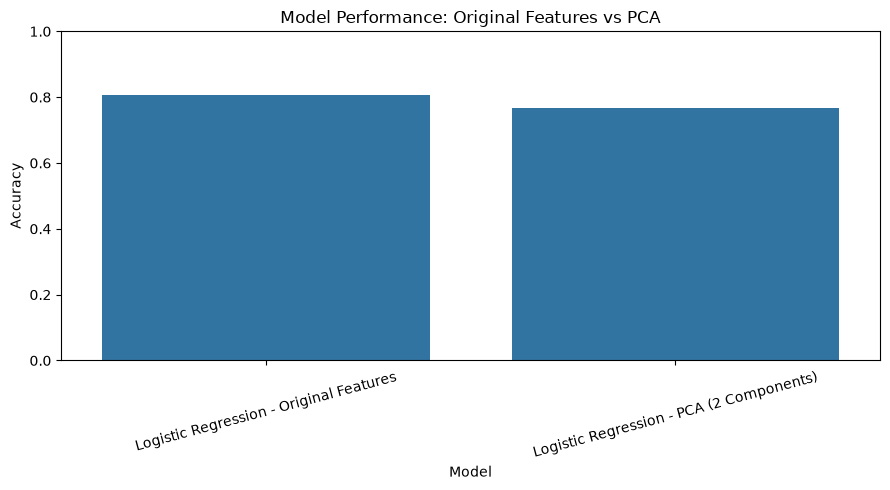

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=performance_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Performance: Original Features vs PCA")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [16]:
variance_report = pd.DataFrame({
    "Component": [
        "Principal Component 1",
        "Principal Component 2"
    ],
    "Explained Variance Ratio": explained_variance,
    "Explained Variance (%)": explained_variance * 100
})

print("Variance Analysis:")
print(variance_report)

print("\nTotal Variance Retained:",
      round(explained_variance.sum() * 100, 2), "%")

Variance Analysis:
               Component  Explained Variance Ratio  Explained Variance (%)
0  Principal Component 1                  0.332462               33.246151
1  Principal Component 2                  0.119803               11.980321

Total Variance Retained: 45.23 %


In [17]:
performance_comparison.to_csv(
    "pca_performance_comparison.csv",
    index=False
)

variance_report.to_csv(
    "pca_variance_analysis.csv",
    index=False
)

print("Reports saved successfully!")

Reports saved successfully!


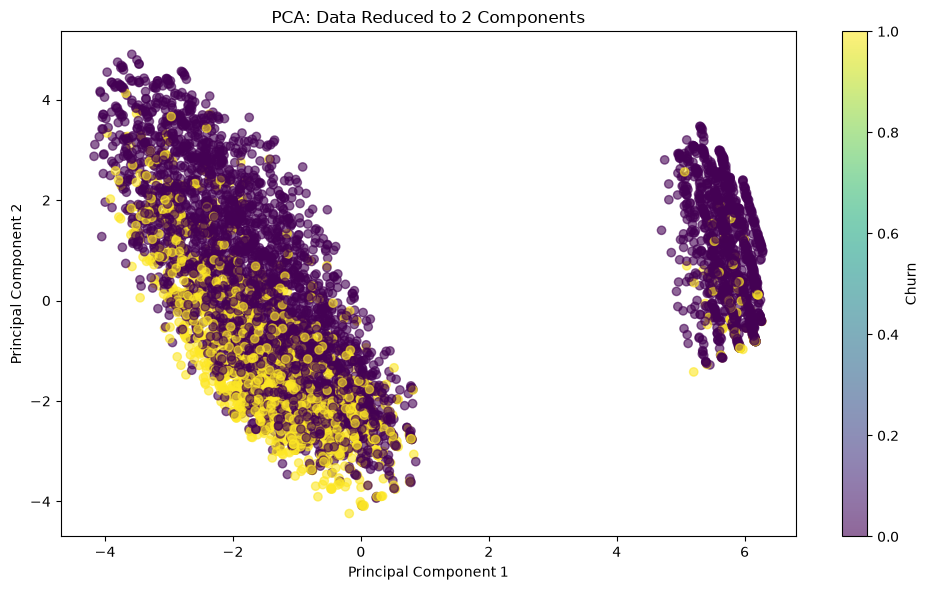

PCA visualization saved successfully!


In [18]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Data Reduced to 2 Components")
plt.colorbar(scatter, label="Churn")
plt.tight_layout()

plt.savefig("pca_2d_visualization.png", dpi=300)
plt.show()

print("PCA visualization saved successfully!")

In [19]:
print("PCA ANALYSIS")
print("-" * 40)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of components: {X_train_pca.shape[1]}")

print(f"\nPC1 variance: {explained_variance[0] * 100:.2f}%")
print(f"PC2 variance: {explained_variance[1] * 100:.2f}%")
print(f"Total variance retained: {explained_variance.sum() * 100:.2f}%")

print(f"\nBaseline accuracy: {baseline_accuracy:.4f}")
print(f"PCA accuracy: {pca_accuracy:.4f}")

print("\nPCA successfully reduced the dimensionality of the dataset.")

PCA ANALYSIS
----------------------------------------
Original number of features: 30
Reduced number of components: 2

PC1 variance: 33.25%
PC2 variance: 11.98%
Total variance retained: 45.23%

Baseline accuracy: 0.8070
PCA accuracy: 0.7679

PCA successfully reduced the dimensionality of the dataset.
